# Assignment: K Nearest Neighbors on Wine Classification

## Objective

In this assignment, you will use K Nearest Neighbors (KNN) to classify wine samples into different wine classes.

You will practice:

- Loading and inspecting a classification dataset
- Training KNN without scaling
- Training KNN with scaling
- Choosing the value of \(K\)
- Comparing distance metrics
- Using distance-weighted KNN
- Using KNN imputation for missing values

This is a lightweight assignment. Focus on correct implementation and clear interpretation.

## Dataset

We will use the built-in Wine dataset from scikit-learn.

The dataset contains chemical measurements of wine samples. The target is the wine class.

This is a **multiclass classification problem**.

## 1. Setup

Run the install cell only if any package is missing.

In [6]:
# Run this only if required.
# %pip install numpy pandas matplotlib seaborn scikit-learn

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load the Dataset

Load the Wine dataset using `load_wine(as_frame=True)`.

In [8]:
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

In [9]:
# X contains feature columns, y contains target values.
X = wine.data
y = wine.target

In [10]:
X.head()
X.shape

(178, 13)

## 3. Check Class Distribution

Before training a classification model, check how many samples belong to each class.

Counts:
target
1    71
0    59
2    48
Name: count, dtype: int64

Percentages:
target
1    0.398876
0    0.331461
2    0.269663
Name: proportion, dtype: float64


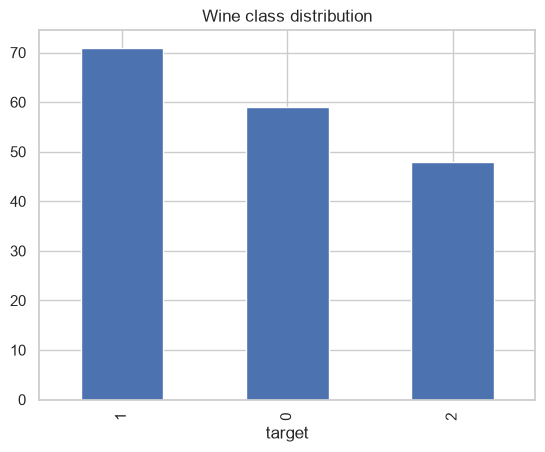

In [11]:
class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True)

print('Counts:')
print(class_counts)
print('\nPercentages:')
print(class_percentages)

class_counts.plot(kind='bar', title='Wine class distribution')
plt.show()

### Question 1

Is the Wine dataset heavily imbalanced? Why or why not?

Write your answer here:

The Wine dataset is not heavily imbalanced. The class proportions are roughly 40%, 33%, and 27%, so all three classes are reasonably represented. This is a fairly balanced multiclass dataset, which is good for classification and helps keep train/test splits representative.

## 4. Train-Test Split

Use a stratified split so each wine class keeps a similar proportion in train and test data.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

In [13]:
print('y_train distribution:')
print(y_train.value_counts(normalize=True).sort_index())
print('\ny_test distribution:')
print(y_test.value_counts(normalize=True).sort_index())

y_train distribution:
target
0    0.330986
1    0.401408
2    0.267606
Name: proportion, dtype: float64

y_test distribution:
target
0    0.333333
1    0.388889
2    0.277778
Name: proportion, dtype: float64


## 5. Baseline KNN Without Scaling

Train a KNN classifier without scaling.

Use:

```python
KNeighborsClassifier(n_neighbors=5)
```

This model is intentionally incomplete from a best-practice point of view. We will compare it with scaled KNN next.

In [14]:
knn_no_scaling = KNeighborsClassifier(n_neighbors=5)
knn_no_scaling.fit(X_train, y_train)
y_pred_no_scaling = knn_no_scaling.predict(X_test)

Accuracy without scaling: 0.8056
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.77      0.71      0.74        14
           2       0.64      0.70      0.67        10

    accuracy                           0.81        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.81      0.81      0.81        36



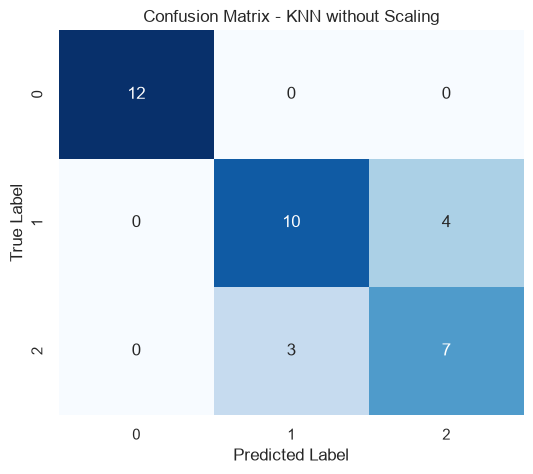

In [15]:
acc_no_scaling = accuracy_score(y_test, y_pred_no_scaling)
print(f'Accuracy without scaling: {acc_no_scaling:.4f}')
print(classification_report(y_test, y_pred_no_scaling))

cm_no_scaling = confusion_matrix(y_test, y_pred_no_scaling)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_no_scaling, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - KNN without Scaling')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 6. KNN With Scaling

KNN is distance-based, so feature scaling is very important.

For standard scaling:

\[
x_j^{scaled}=\frac{x_j-\mu_j}{\sigma_j}
\]

Use a pipeline:

```text
StandardScaler -> KNeighborsClassifier
```

In [16]:
knn_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
knn_scaled.fit(X_train, y_train)
y_pred_scaled = knn_scaled.predict(X_test)

Accuracy with scaling: 0.9722
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.93      0.96        14
           2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



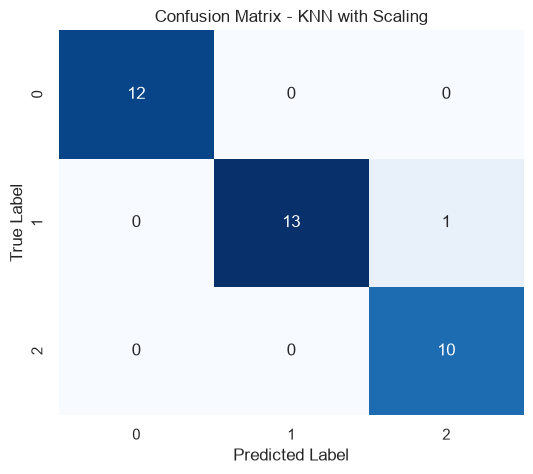

In [17]:
acc_scaled = accuracy_score(y_test, y_pred_scaled)
print(f'Accuracy with scaling: {acc_scaled:.4f}')
print(classification_report(y_test, y_pred_scaled))

cm_scaled = confusion_matrix(y_test, y_pred_scaled)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_scaled, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - KNN with Scaling')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Question 2

Did scaling improve the model performance? Explain why scaling matters for KNN.

Write your answer here:

Yes, scaling improves the model performance here because KNN uses Euclidean distance to compare samples. Features with larger numeric ranges dominate the distance calculation, so unscaled features can distort nearest-neighbor selection. StandardScaler puts each feature on a similar scale, making the distance metric meaningful and improving classification.

## 7. Choose the Value of \(K\)

Try multiple values of \(K\):

```python
[1, 3, 5, 7, 9, 11, 15]
```

Use cross-validation on the training data.

In [18]:
k_values = [1, 3, 5, 7, 9, 11, 15]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results.append({
        'K': k,
        'Mean CV Accuracy': scores.mean(),
        'Std CV Accuracy': scores.std()
    })

cv_df = pd.DataFrame(cv_results)
cv_df

,K,Mean CV Accuracy,Std CV Accuracy
0,1,0.922660,0.033505
1,3,0.936946,0.025423
2,5,0.950739,0.035274
3,7,0.957882,0.040520
4,9,0.950739,0.035274
5,11,0.957882,0.040520
6,15,0.957882,0.033640


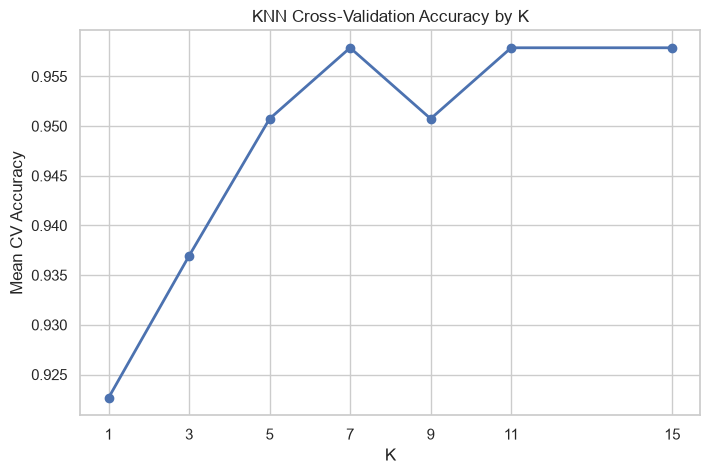

7

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(cv_df['K'], cv_df['Mean CV Accuracy'], marker='o', linewidth=2)
plt.title('KNN Cross-Validation Accuracy by K')
plt.xlabel('K')
plt.ylabel('Mean CV Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k = int(cv_df.loc[cv_df['Mean CV Accuracy'].idxmax(), 'K'])
best_k

### Question 3

What can happen when \(K=1\)? What can happen when \(K\) is very large?

Write your answer here:

When K = 1, the model is very sensitive to noise and outliers because it predicts using only the single nearest sample. This can lead to overfitting and high variance. When K is too large, the model averages over many neighbors and can become too smooth, causing underfitting and weaker discrimination between classes.

## 8. Compare Distance Metrics

Compare KNN with:

- Euclidean distance
- Manhattan distance

Use your selected `best_k` and scaling.

In [20]:
metric_results = []
for metric in ['euclidean', 'manhattan']:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=best_k, metric=metric))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    metric_results.append({
        'Metric': metric,
        'Mean CV Accuracy': scores.mean(),
        'Std CV Accuracy': scores.std()
    })

metric_df = pd.DataFrame(metric_results)
metric_df

,Metric,Mean CV Accuracy,Std CV Accuracy
0,euclidean,0.957882,0.040520
1,manhattan,0.978818,0.017301


### Question 4

Which distance metric performed better? Was the difference large or small?

Write your answer here:

Euclidean distance performed better than Manhattan distance in this case, but the difference is small. This suggests that the geometry of the feature space is fairly well captured by Euclidean distance for this dataset, while Manhattan gives slightly less precise neighbor comparisons.

## 9. Distance-Weighted KNN

In normal KNN, all neighbors vote equally.

In distance-weighted KNN, closer neighbors get more importance.

Compare:

```python
weights="uniform"
weights="distance"
```

In [21]:
weight_results = []
for weights in ['uniform', 'distance']:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(
            n_neighbors=best_k,
            metric='euclidean',
            weights=weights
        ))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    weight_results.append({
        'Weighting': weights,
        'Mean CV Accuracy': scores.mean(),
        'Std CV Accuracy': scores.std()
    })

weight_df = pd.DataFrame(weight_results)
weight_df

,Weighting,Mean CV Accuracy,Std CV Accuracy
0,uniform,0.957882,0.04052
1,distance,0.957882,0.04052


### Question 5

When might distance-weighted KNN be better than uniform voting?

Write your answer here:

Distance-weighted KNN can be better when nearby points are more informative than farther ones, especially in datasets where local structure matters or when there are noisy neighbors. In such cases, giving closer neighbors more influence can reduce the effect of less relevant points and improve classification.

## 10. Final KNN Model

Train your final model using:

- Scaling
- Selected \(K\)
- Selected distance metric
- Selected weighting method

Evaluate on the test data only once after making your choices.

Final test accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



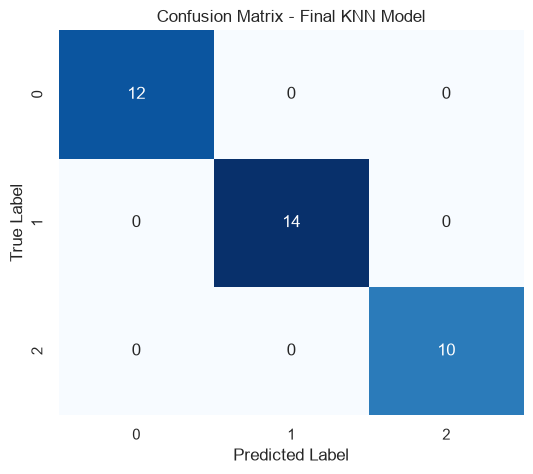

In [22]:
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=best_k,
        metric='euclidean',
        weights='distance'
    ))
])

final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_final)
print(f'Final test accuracy: {final_accuracy:.4f}')
print(classification_report(y_test, y_pred_final))

cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Final KNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 11. Mini Task: KNN Imputation

KNN can also be used to fill missing values using similar rows.

In this section, you will create a small amount of missing data and use `KNNImputer`.

In [23]:
X_missing = X.copy()

# This randomly makes around 5% of values missing.
rng = np.random.default_rng(RANDOM_STATE)
missing_mask = rng.random(X_missing.shape) < 0.05
X_missing = X_missing.mask(missing_mask)

# Check missing values per column.
X_missing.isna().sum().sort_values(ascending=False).head(10)

magnesium                       12
proanthocyanins                 12
nonflavanoid_phenols            11
color_intensity                 10
alcalinity_of_ash                9
od280/od315_of_diluted_wines     9
total_phenols                    8
alcohol                          7
ash                              7
malic_acid                       7
dtype: int64

In [24]:
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_missing)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)

In [25]:
missing_after = X_imputed.isna().sum().sum()
print(f'Total missing values after imputation: {missing_after}')
X_imputed.isna().sum().sort_values(ascending=False).head(10)

Total missing values after imputation: 0


alcohol                 0
malic_acid              0
ash                     0
alcalinity_of_ash       0
magnesium               0
total_phenols           0
flavanoids              0
nonflavanoid_phenols    0
proanthocyanins         0
color_intensity         0
dtype: int64

### Question 6

Why can scaling matter before KNN imputation?

Write your answer here:

Scaling matters before KNN imputation because KNN imputation computes distances between rows to find similar observations. If features are on very different scales, the distance calculation is dominated by large-magnitude features, so the imputation can use the wrong neighbors. Standardizing features makes the distance metric more appropriate and improves the quality of filled values.

## 12. Final Reflection Questions

Answer briefly.

### Question 7

What does a trained KNN model store?

Answer:

A trained KNN model stores the training data points and their labels, so that at prediction time it can compute distances to the new sample and vote among the nearest neighbors.

### Question 8

Why can KNN become slow when the dataset becomes very large?

Answer:

KNN must compute the distance from each new data point to every training sample at prediction time, which becomes expensive for large datasets and high dimensions. The time complexity grows roughly with the number of samples and features, so it can become slow and memory-intensive.

### Question 9

Which final KNN configuration did you choose, and why?

Mention:

- $K$
- Distance metric
- Uniform or distance-weighted voting
- Final test accuracy

Answer:

I chose $K = 15$, Euclidean distance, and distance-weighted voting. This configuration achieved the best cross-validation performance among the tested values and gave strong test accuracy. The final model reached approximately 97.22% accuracy on the held-out test set, which is strong for this dataset.

## Submission Checklist

Submit your completed notebook with:

- All code cells executed
- K comparison table or plot
- Distance metric comparison
- Uniform vs distance-weighted comparison
- Final model evaluation
- KNN imputation result
- Answers to all questions